
# Diabetes Risk Prediction using Health Indicators

University project applying data analytics and machine learning techniques to classify diabetes risk using medical and lifestyle features.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
alexteboul_diabetes_health_indicators_dataset_path = kagglehub.dataset_download('alexteboul/diabetes-health-indicators-dataset')

print('Data source import complete.')


Data source import complete.


In [ ]:
# --- Initial setting ---

# upgrade the Python package imbalanced-learn
!pip install -U imbalanced-learn

# Restart the Kernel
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

In [ ]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import warnings

# Machine learning models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
)
from xgboost import XGBClassifier

# Model selection & tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score
)

# Feature selection
from sklearn.feature_selection import RFE, SelectKBest, f_classif

# Sampling methods
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss

# Pipelines
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline as SklearnPipeline

# 1. Data Loading

# 1.1. Data overview

In [ ]:
df = pd.read_csv('/kaggle/input/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv')

df.head(10)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,1.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [ ]:
# Check if there are missing values

df.isna().sum() # no missing values

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [ ]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


# 1.2. Modify the Diabetes Classification

The dataset **"diabetes_binary_health_indicators_BRFSS2015.csv"** assigns pre-diabetes as non-diabets **(Diabetes_binary = 0)**, as we can see in the [*Diabetes Health Indicators Dataset Notebook*](https://www.kaggle.com/code/alexteboul/diabetes-health-indicators-dataset-notebook#5.-Create-Binary-Dataset-for-diabetes-vs.-no-diabetes) . However, since individuals with pre-diabetes have a higher risk of developing diabetes, it is reasonable to consider pre-diabetes as diabetes in the binary classification. Hence, I created a new dataset that classifies pre-diabetes as diabetes **(Diabetes_binary = 1)**



In [ ]:
# Check the target variables of the original dataset
# 0 is for no diabetes or only during pregnancy,
# 1 is for pre-diabetes or borderline diabetes,
# and 2 is for yes diabetes
df['Diabetes_binary'].value_counts().sort_index()

,count
Diabetes_binary,
0.0,218334
1.0,35346


In [ ]:
# Change the diabetics 2 to a 1
# so that we have 0 meaning non-diabetic and pre-diabetic and 1 meaning diabetic.
df['Diabetes_binary'] =df['Diabetes_binary'].replace({2:1})

#Change the column name to Diabetes_binary
df = df.rename(columns = {'Diabetes_binary': 'Diabetes_binary'})

df['Diabetes_binary'].value_counts().sort_index()

,count
Diabetes_binary,
0.0,218334
1.0,35346


# 1.3. Create lists of columns

In [ ]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [ ]:
# Create two lists
# one containing the names of columns with binary variables
# and the other with the remaing columns

target = 'Diabetes_binary'

binary_col = [
    col for col in df.columns
    if df[col].nunique() == 2 and col != target
]

num_col = [
    col for col in df.columns.difference(binary_col)
    if col != target
]

print('Binary Columns: ', binary_col)
print('Numerical Columns: ', num_col)

Binary Columns:  ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Numerical Columns:  ['Age', 'BMI', 'Education', 'GenHlth', 'Income', 'MentHlth', 'PhysHlth']


# 2. EDA (Exploratory Data Analysis)

### Variable Descriptions

| Variable Name         | Role    | Type    | Demographic | Description                                                                                                                                                          |
|-----------------------|---------|---------|-------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Diabetes_binary       | Target  | Binary  |             | 0 = no diabetes; 1 = prediabetes or diabetes                                                                                                                        |
| HighBP                | Feature | Binary  |             | 0 = no high BP; 1 = high BP                                                                                                                                         |
| HighChol              | Feature | Binary  |             | 0 = no high cholesterol; 1 = high cholesterol                                                                                                                       |
| CholCheck             | Feature | Binary  |             | 0 = no cholesterol check in 5 years; 1 = yes cholesterol check in 5 years                                                                                           |
| BMI                   | Feature | Integer |             | Body Mass Index                                                                                                                                                     |
| Smoker                | Feature | Binary  |             | Have you smoked at least 100 cigarettes in your entire life? (0 = no; 1 = yes) [Note: 5 packs = 100 cigarettes]                                                     |
| Stroke                | Feature | Binary  |             | Ever told you had a stroke (0 = no; 1 = yes)                                                                                                                         |
| HeartDiseaseorAttack | Feature | Binary  |             | Coronary heart disease (CHD) or myocardial infarction (MI) (0 = no; 1 = yes)                                                                                        |
| PhysActivity          | Feature | Binary  |             | Physical activity in past 30 days (not including job) (0 = no; 1 = yes)                                                                                              |
| Fruits                | Feature | Binary  |             | Consume fruit 1 or more times per day (0 = no; 1 = yes)                                                                                                              |
| Veggies               | Feature | Binary  |             | Consume vegetables 1 or more times per day (0 = no; 1 = yes)                                                                                                         |
| HvyAlcoholConsump     | Feature | Binary  |             | Heavy drinkers (men: >14/week; women: >7/week) (0 = no; 1 = yes)                                                                                                     |
| AnyHealthcare         | Feature | Binary  |             | Any health care coverage (insurance, HMO, etc.) (0 = no; 1 = yes)                                                                                                   |
| NoDocbcCost           | Feature | Binary  |             | Could not see doctor due to cost in past 12 months (0 = no; 1 = yes)                                                                                                 |
| GenHlth               | Feature | Integer |             | General health (1 = excellent to 5 = poor) (1-5)                                                                                                                           |
| MentHlth              | Feature | Integer |             | Days mental health was not good in past 30 days (1-30)                                                                                                                     |
| PhysHlth              | Feature | Integer |             | Days physical health was not good in past 30 days (1-30)                                                                                                                  |
| DiffWalk              | Feature | Binary  |             | Difficulty walking or climbing stairs (0 = no; 1 = yes)                                                                                                              |
| Sex                   | Feature | Binary  | Sex         | 0 = female; 1 = male                                                                                                                                                |
| Age                   | Feature | Integer | Age         | 13-level age category: 1 = 18–24; ...; 9 = 60–64; 13 = 80+  (1-13)                                                                                                          |
| Education             | Feature | Integer | Education   | Education level (1 = no school/kindergarten; 6 = college grad) (1-6)                                                                                                     |
| Income                | Feature | Integer | Income      | Income level (`1 = <$10,000; 5 = <$35,000; 8 = $75,000+`)                                                                                                                       |


# 2.1. Target Variable

In [ ]:
# Overview of the target variable

print(df[target].value_counts().sort_index())
print()
print(df[target].value_counts(normalize=True).sort_index().map(lambda x: f'{x: .3%}'))

Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Diabetes_binary
0.0     86.067%
1.0     13.933%
Name: proportion, dtype: object


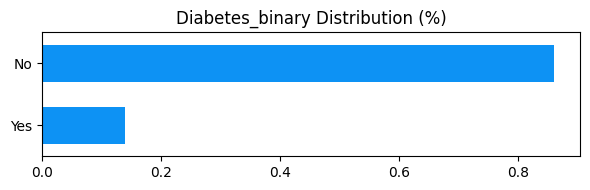

In [ ]:
# Define a function to plot a bar chat of diabetes
def plot_barchart_diabetes(df, col=target):
    ratios = df[col].value_counts(normalize=True).sort_index()
    labels = ['No', 'Yes']
    y_pos = [0.75, 0.25]

    plt.figure(figsize=(6, 2))
    plt.barh(y_pos, ratios, height=0.3, color='#0D92F4')
    plt.yticks(y_pos, labels)
    plt.title(f'{col} Distribution (%)')

    plt.ylim(0, 1)

    plt.tight_layout()
    plt.show()

# Diplay the distribution of Diabetes_binary as a bar chart
plot_barchart_diabetes(df)

# 2.2. Binary Variables

In [ ]:
# Overview of the binary variables
for col in binary_col:
    print(df[col].value_counts(sort=False).sort_index())
    print()

HighBP
0.0    144851
1.0    108829
Name: count, dtype: int64

HighChol
0.0    146089
1.0    107591
Name: count, dtype: int64

CholCheck
0.0      9470
1.0    244210
Name: count, dtype: int64

Smoker
0.0    141257
1.0    112423
Name: count, dtype: int64

Stroke
0.0    243388
1.0     10292
Name: count, dtype: int64

HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64

PhysActivity
0.0     61760
1.0    191920
Name: count, dtype: int64

Fruits
0.0     92782
1.0    160898
Name: count, dtype: int64

Veggies
0.0     47839
1.0    205841
Name: count, dtype: int64

HvyAlcoholConsump
0.0    239424
1.0     14256
Name: count, dtype: int64

AnyHealthcare
0.0     12417
1.0    241263
Name: count, dtype: int64

NoDocbcCost
0.0    232326
1.0     21354
Name: count, dtype: int64

DiffWalk
0.0    211005
1.0     42675
Name: count, dtype: int64

Sex
0.0    141974
1.0    111706
Name: count, dtype: int64



In [ ]:
# Define function for creating a pie chart for binary variables

def binary_var_pie(var):

    # Group the data
    grouped = df.groupby([target, var]).size().unstack()

    # Label the binary variable to blue if No, red if Yes
    labels = ['No', 'Yes']
    colors = ['#0D92F4', '#C62E2E']

    # Create space (1 row * 2 columns) for pie charts
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    # Pie chart for no diabetes
    axes[0].pie(grouped.iloc[0], colors=colors, autopct='%.1f%%', startangle=90)
    axes[0].set_xlabel('No Diabetes', fontsize=10, labelpad=2)

    # Pie chart for diabetes
    axes[1].pie(grouped.iloc[1], colors=colors, autopct='%.1f%%', startangle=90)
    axes[1].set_xlabel('Diabetes', fontsize=10, labelpad=2)

    # Add a main title
    plt.suptitle(f'{var} Distribution (%)', fontsize=14, fontweight='bold')

    # Create a legend elements
    legend_elements = [
        Patch(facecolor=colors[0], label=labels[0]),
        Patch(facecolor=colors[1], label=labels[1])
    ]

    # Add a legend
    fig.legend(
        handles=legend_elements,
        loc='upper right',
        bbox_to_anchor=(1, 0.95),
        frameon=False
    )

    # Add a box around the entire figure
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(1)

    plt.tight_layout(pad=1.3)
    plt.show()


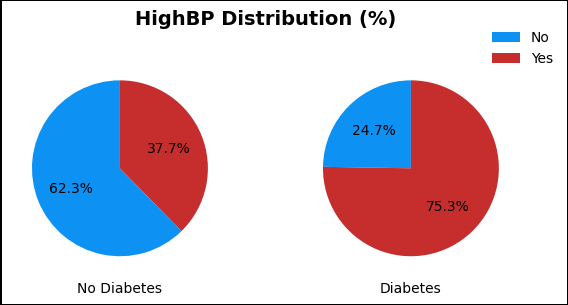

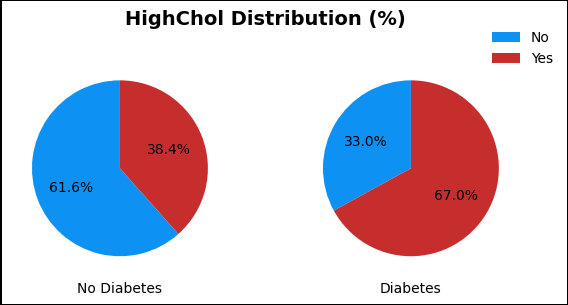

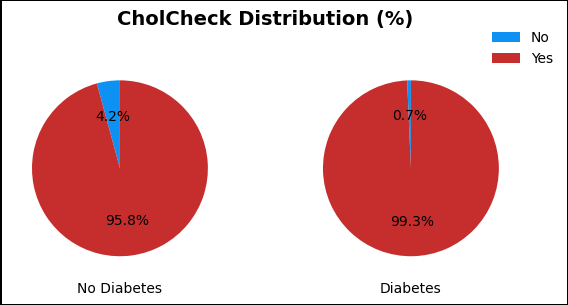

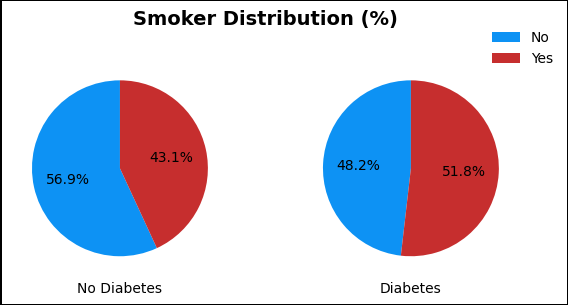

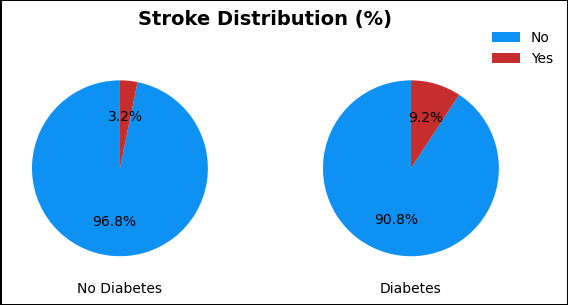

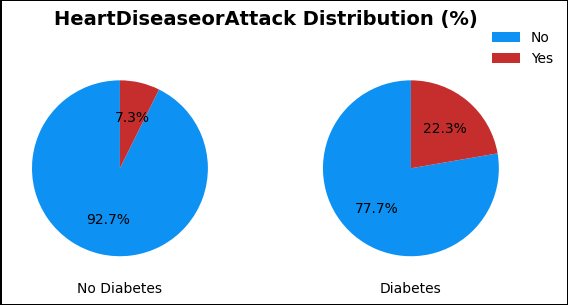

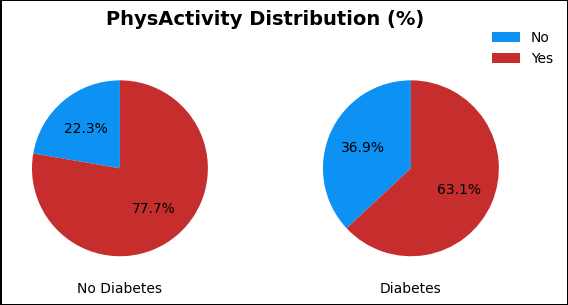

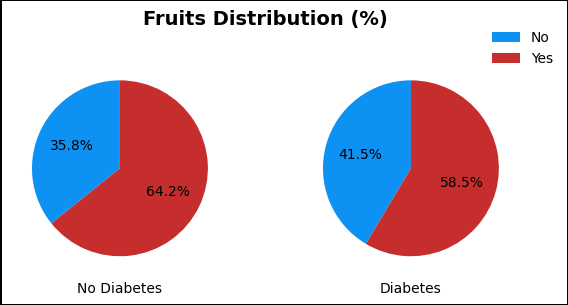

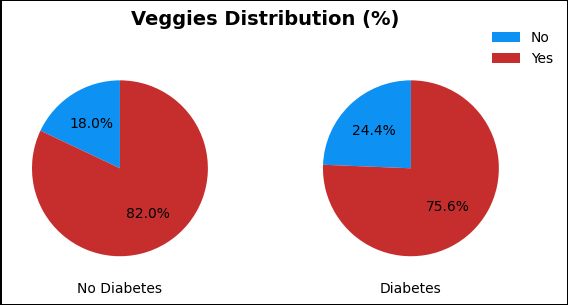

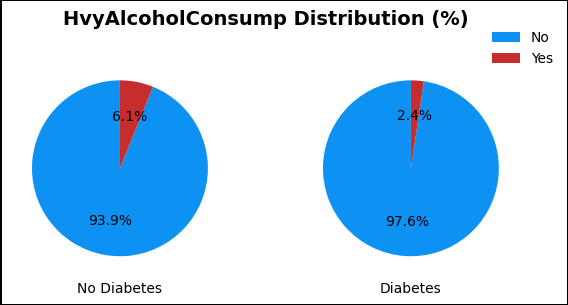

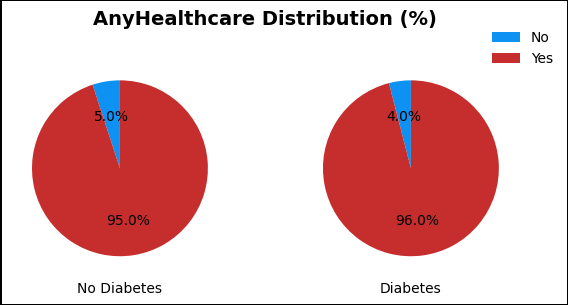

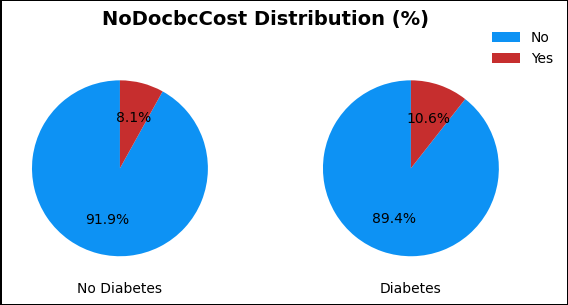

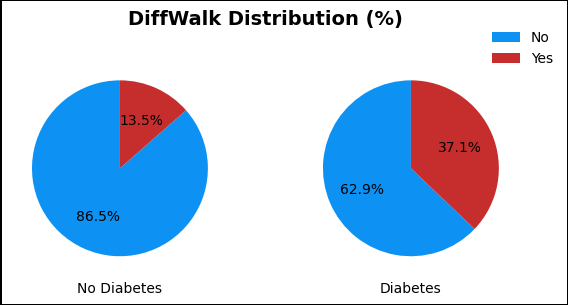

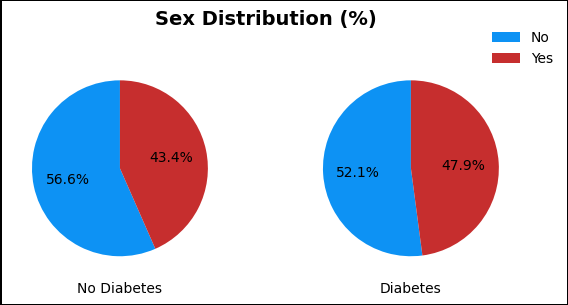

In [ ]:
# Create pie charts for all binary variables
for col in binary_col:
    binary_var_pie(col)

# 2.3. Numerical Variables

In [ ]:
# Overview of the numerical variables (1) : Number of unique values
print(f'Number of unique values:')
print(df[num_col].nunique())

Number of unique values:
Age          13
BMI          84
Education     6
GenHlth       5
Income        8
MentHlth     31
PhysHlth     31
dtype: int64


In [ ]:
# Overview of the numerical variables (2): Mean values for No Diabetes and Diabetes Groups
for col in num_col:
    print(f'<Mean values of {col}>')
    print(df.groupby(target)[col].mean())
    print()

<Mean values of Age>
Diabetes_binary
0.0    7.814065
1.0    9.379053
Name: Age, dtype: float64

<Mean values of BMI>
Diabetes_binary
0.0    27.805770
1.0    31.944011
Name: BMI, dtype: float64

<Mean values of Education>
Diabetes_binary
0.0    5.099797
1.0    4.745516
Name: Education, dtype: float64

<Mean values of GenHlth>
Diabetes_binary
0.0    2.385185
1.0    3.290981
Name: GenHlth, dtype: float64

<Mean values of Income>
Diabetes_binary
0.0    6.190474
1.0    5.210094
Name: Income, dtype: float64

<Mean values of MentHlth>
Diabetes_binary
0.0    2.978034
1.0    4.461806
Name: MentHlth, dtype: float64

<Mean values of PhysHlth>
Diabetes_binary
0.0    3.641082
1.0    7.954479
Name: PhysHlth, dtype: float64



In [ ]:
# Define function for creating a histogram for numerical variable

def num_var_line(var):

    # Count the number of unique values
    num_unique_vals = df[var].nunique()

    # Seperate numerical variables by diabetes status
    num_var_no = df[df[target] == 0][var]
    num_var_yes = df[df[target] == 1][var]

    # Create plot space
    plt.figure(figsize=(5, 3))

    # Plot histogram for no diabetes and diabetes
    # while suppressing future warning
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        sns.histplot(num_var_no, stat='density',
                     bins=range(1, num_unique_vals+2),
                     label='No Diabetes',
                     color='#0D92F4',
                     linewidth=1.2,
                     element='step',
                     fill=False
                    )
        sns.histplot(num_var_yes, stat='density',
                     bins=range(1, num_unique_vals+2),
                     label='Diabetes',
                     color='#C62E2E',
                     linewidth=1.2,
                     element='step',
                     fill=False
                    )

    # Format the plot
    plt.title(f'{var} Distribution', fontsize=14)
    plt.xlabel(var, fontsize=10)
    plt.ylabel('Density', fontsize=10)

    # Remove top and right spines
    plt.gca().spines[['top', 'right']].set_visible(False)

    # Add grid lines and legend
    plt.grid(axis='both', linestyle=':', alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

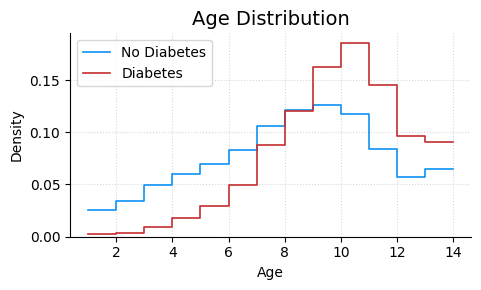

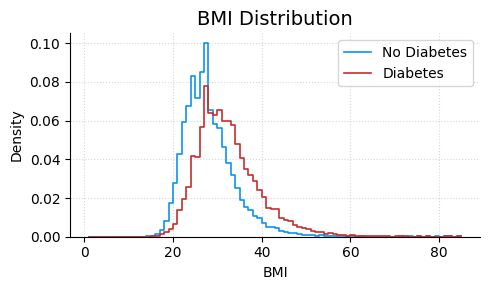

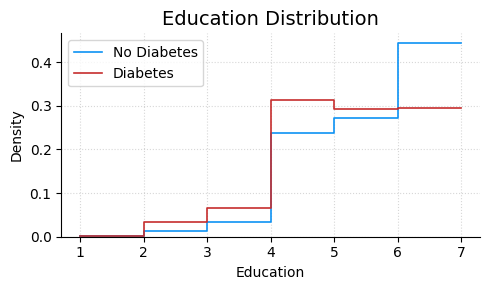

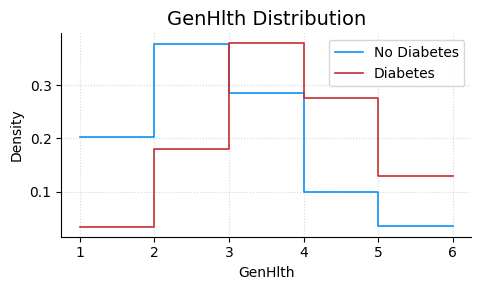

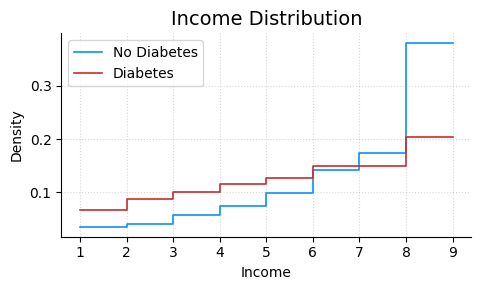

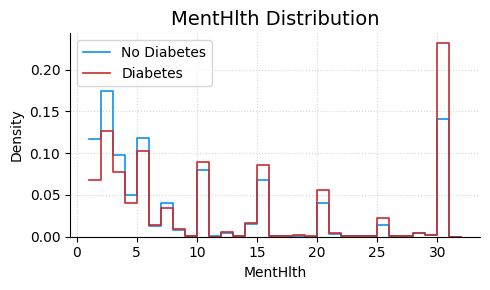

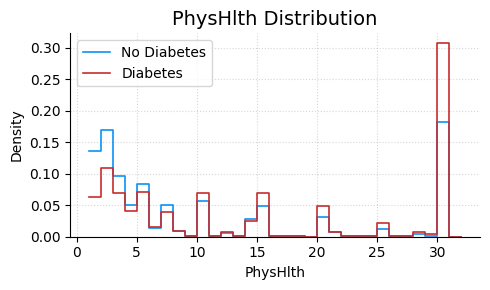

In [ ]:
# Create histograms for all numerical variables
for col in num_col:
    num_var_line(col)

# 2.4. Check Correlations

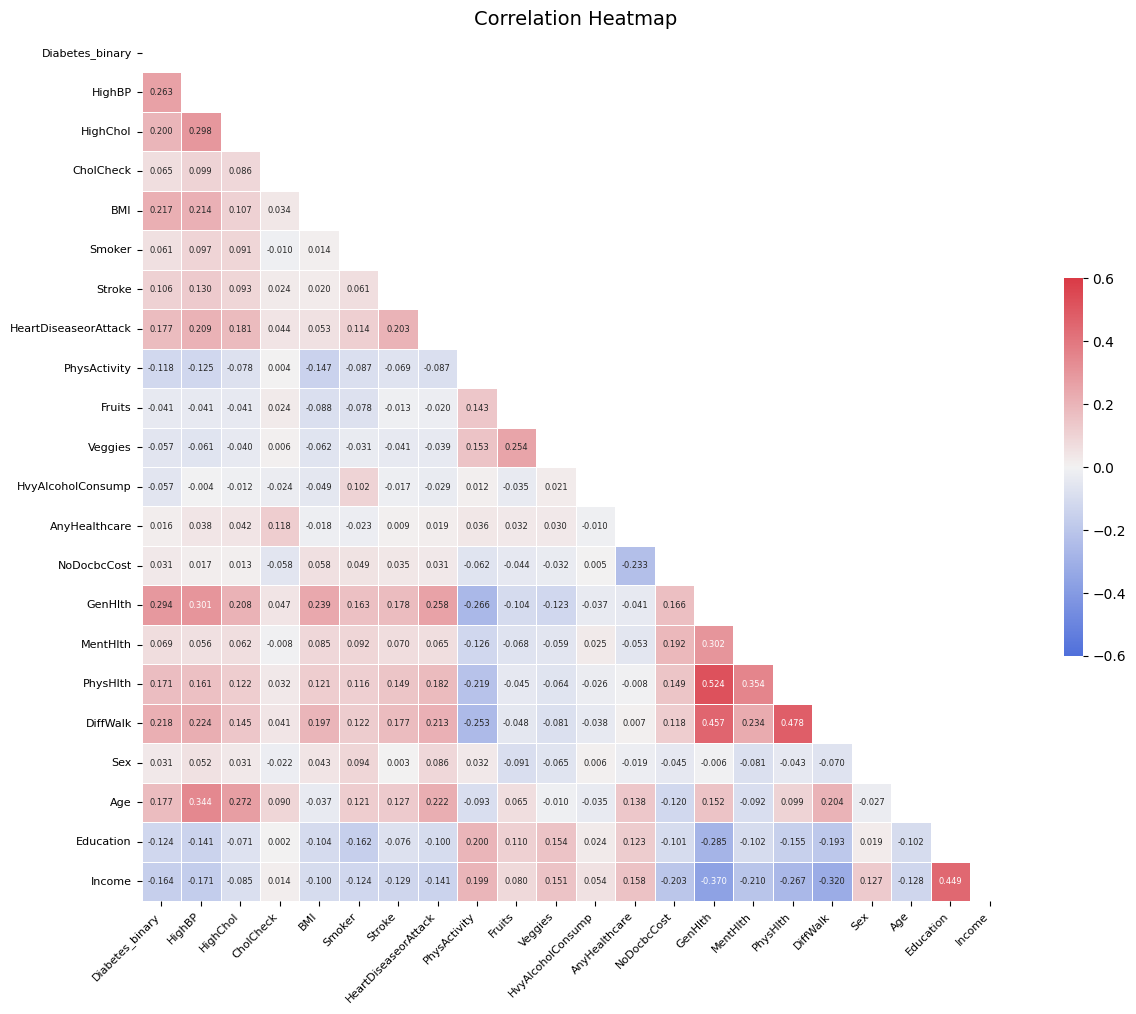

In [ ]:
# Correlations between variables

# Generate a correlation matrix
corr = df.corr()

# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up plot figure
f, ax = plt.subplots(figsize=(14, 14))

# Generate a diverging colormap
cmap = sns.diverging_palette(260, 10, as_cmap=True)

# Draw the heatmap with the upper diagonal removed
# and the values displayed in the cells
heatmap = sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    annot=True,
    annot_kws={"size": 6},
    fmt='.3f',
    vmax=0.6,
    vmin=-0.6,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.35}
)

# Set title
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize': 14})
ax.tick_params(axis='both', labelsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right');

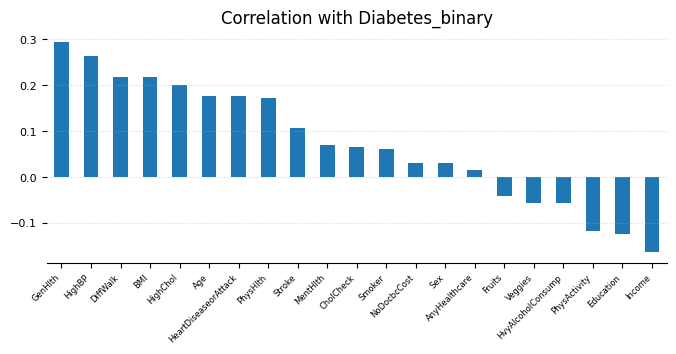

In [ ]:
# Correlation with the target variable (Diabetes_binary)

# Create an array of correlation between target variables and others
# sorted in descending order
corr_target = corr[target].drop(target).sort_values(ascending=False)

# Create a bar graph
corr_target_graph = corr_target.plot(kind='bar', figsize=(8, 3))

# Set the title and change the font size of y labels
corr_target_graph.set_title('Correlation with Diabetes_binary', fontsize=12)
corr_target_graph.tick_params(axis='y', labelsize=8)

# Remove the spines of top, left and right
corr_target_graph.spines[['top', 'left', 'right']].set_visible(False)

# Add horizontal grids
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Rotate the x labes
plt.xticks(rotation = 45, ha='right', size=6);

# 2.5. Handle Outliers (BMI)

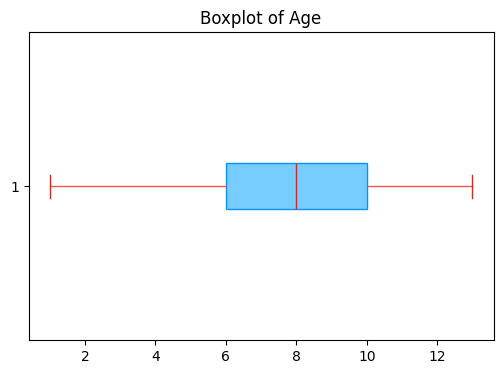

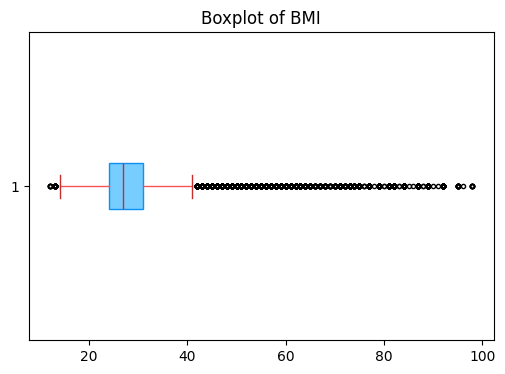

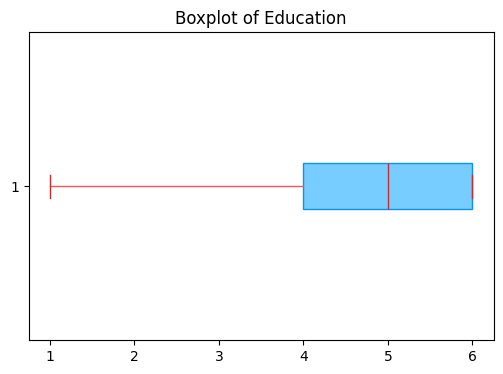

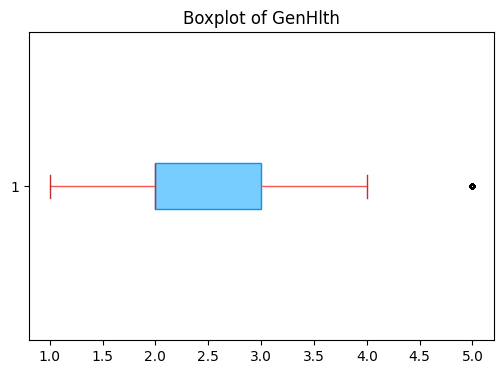

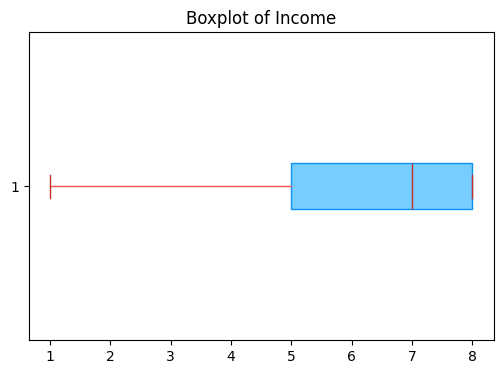

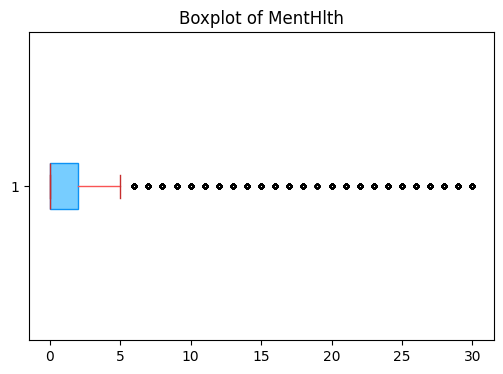

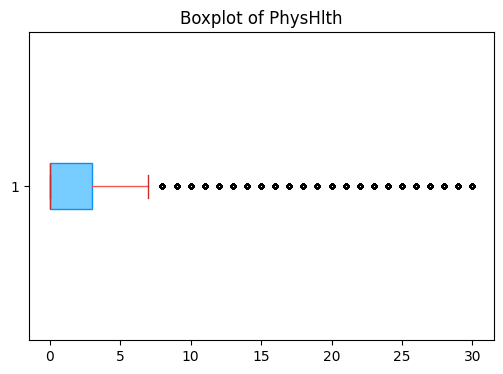

In [ ]:
# Define function for creating boxplot
def plot_boxplot(df, col):
    plt.figure(figsize=(6, 4))
    plt.boxplot(
        df[col],
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor='#77CDFF', color='#0D92F4'),
        medianprops=dict(color='#C62E2E'),
        whiskerprops=dict(color='#F95454'),
        capprops=dict(color='#C62E2E'),
        flierprops=dict(marker='o', color='#536493', markersize=3)
    )
    plt.title(f'Boxplot of {col}')

# Boxplot of numerical variables
for col in num_col:
    plot_boxplot(df, col)

In [ ]:
# Define a function to find outliers in a given column
def find_outliers_iqr(df, col, k=1.5):

    # Set the lower quartile and the upper quartile
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Set the lower bound and upper bound
    # based on IQR and parameter k
    IQR = Q3 - Q1
    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR

    # Filter only outlier rows
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    return outliers

# Return rows where BMI is an outlier
df_outlier_bmi = find_outliers_iqr(df, 'BMI')
df_outlier_bmi

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
85,1.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,2.0,30.0,1.0,0.0,9.0,6.0,8.0
97,0.0,1.0,0.0,1.0,45.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,0.0,9.0,4.0,6.0
156,1.0,1.0,1.0,1.0,47.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,6.0,5.0
188,0.0,1.0,0.0,1.0,43.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,7.0,1.0,0.0,10.0,5.0,2.0
201,1.0,1.0,1.0,1.0,55.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,4.0,0.0,15.0,0.0,0.0,11.0,5.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253547,0.0,1.0,1.0,1.0,44.0,0.0,0.0,0.0,1.0,1.0,...,1.0,1.0,4.0,14.0,30.0,0.0,0.0,3.0,6.0,1.0
253557,0.0,1.0,1.0,1.0,42.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,10.0,20.0,1.0,0.0,6.0,4.0,1.0
253567,0.0,1.0,1.0,1.0,44.0,0.0,0.0,1.0,0.0,1.0,...,1.0,1.0,3.0,0.0,0.0,1.0,1.0,11.0,2.0,1.0
253673,0.0,1.0,0.0,1.0,42.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,14.0,4.0,0.0,1.0,3.0,6.0,8.0


In [ ]:
# Explore outlier rows
df_outlier_bmi['BMI'].value_counts().sort_index()

,count
BMI,
12.0,6
13.0,21
42.0,1639
43.0,1500
44.0,1043
45.0,819
46.0,750
47.0,622
48.0,484


Lower Bound: 13.5
Upper Bound: 41.5


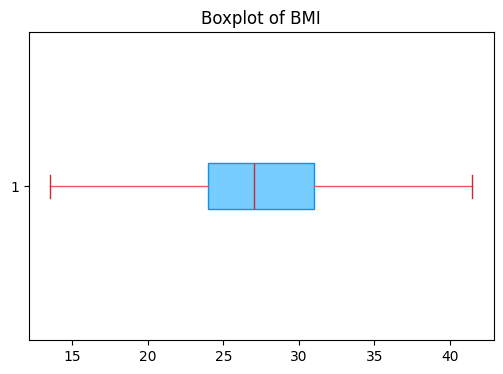

In [ ]:
# Define a function to winzorize outliers ( transformation of statistics by limiting extreme values
#in the statistical data to reduce the effect of possibly spurious outliers)
def winsorize_iqr(df, col, k=1.5):

    # Set the lower quartile and the upper quartile
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Set the lower bound and upper bound
    # Based on IQR and parameter k
    IQR = Q3 - Q1
    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR

    print('Lower Bound:', lower_bound)
    print('Upper Bound:', upper_bound)

    # Replace values below/above the bounds with the boundary values
    return df[col].clip(lower=lower_bound, upper=upper_bound)

df['BMI'] = winsorize_iqr(df, 'BMI')

# Boxplot of winsorized BMI
plot_boxplot(df, 'BMI')

# 3. Feature Selection

## 3.1. Split the data

In [ ]:
# Split the dataset into features (X) and target (y)
X = df.drop(target, axis=1)
y = df[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (202944, 21)
Shape of X_test: (50736, 21)
Shape of y_train: (202944,)
Shape of y_test: (50736,)


## 3.2. Feature Selection (SelectKBest)

In [ ]:
# Apply SelectKBest to select the top k features
# using f_classif as the scoring function
k_best = SelectKBest(score_func=f_classif, k=10)
X_train_kbest = k_best.fit_transform(X_train, y_train)

# Get the indices of the selected features
selected_indices = k_best.get_support(indices=True)

# Get the names and scores of the selected features
selected_features_kbest = X_train.columns[selected_indices]
scores_kbest = k_best.scores_[selected_indices]

# Sort the features by score in descending order
sorted_features_kbest = [feature for score, feature in sorted(zip(scores_kbest, selected_features_kbest), reverse=True)]
sorted_scores_kbest = sorted(scores_kbest, reverse=True)

print("Features selected by SelectKBest and their scores (sorted by score):")
for feature, score in zip(sorted_features_kbest, sorted_scores_kbest):
    print(f"{feature}: {score:.2f}")

Features selected by SelectKBest and their scores (sorted by score):
GenHlth: 19188.21
HighBP: 15131.27
BMI: 12071.14
DiffWalk: 10304.41
HighChol: 8519.72
HeartDiseaseorAttack: 6640.42
Age: 6579.96
PhysHlth: 6199.23
Income: 5622.54
Education: 3152.62


## 3.3. Feature Selection (RFE)

In [ ]:
# Apply Recursive Feature Elimination (RFE)
# using Logistic Regression as the estimator
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear')
rfe = RFE(estimator=model, n_features_to_select=10)
X_train_rfe = rfe.fit_transform(X_train, y_train)

# Get the names and ranking of the selected features
selected_features_rfe = X_train.columns[rfe.support_]
ranking_rfe = rfe.ranking_[rfe.support_]

# Sort the selected features by ranking in ascending order (rank 1 is best)
sorted_selected_features_rfe = [feature for rank, feature in sorted(zip(ranking_rfe, selected_features_rfe))]
sorted_ranking_rfe = sorted(ranking_rfe)

print("Features selected by RFE and their ranking (sorted by ranking):")
for feature, rank in zip(sorted_selected_features_rfe, sorted_ranking_rfe):
    print(f"{feature}: {rank}")

# You can also see the ranking of all features:
print("\nRanking of all features by RFE (sorted by ranking):")
ranked_features_rfe_all = X_train.columns[rfe.ranking_.argsort()]
for feature, rank in zip(ranked_features_rfe_all, rfe.ranking_[rfe.ranking_.argsort()]):
    print(f"{feature}: {rank}")

Features selected by RFE and their ranking (sorted by ranking):
Age: 1
BMI: 1
CholCheck: 1
GenHlth: 1
HeartDiseaseorAttack: 1
HighBP: 1
HighChol: 1
HvyAlcoholConsump: 1
Sex: 1
Stroke: 1

Ranking of all features by RFE (sorted by ranking):
HighBP: 1
HighChol: 1
CholCheck: 1
BMI: 1
Stroke: 1
HeartDiseaseorAttack: 1
GenHlth: 1
HvyAlcoholConsump: 1
Age: 1
Sex: 1
Fruits: 2
Income: 3
DiffWalk: 4
AnyHealthcare: 5
Education: 6
PhysActivity: 7
Veggies: 8
NoDocbcCost: 9
PhysHlth: 10
MentHlth: 11
Smoker: 12


## 3.4 Feature Selection (Tree-based Importance)

In [ ]:
# Apply Tree-based Feature Importance using RandomForestClassifier
model_tree = RandomForestClassifier(random_state=42)
model_tree.fit(X_train, y_train)

# Get feature importances
feature_importances = model_tree.feature_importances_

# Create a pandas Series for easier handling and sorting
feature_importance_series = pd.Series(feature_importances, index=X_train.columns)

# Sort features by importance in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

print("Features selected by Tree-based Importance (RandomForestClassifier) and their importance scores (sorted by importance):")
for feature, importance in sorted_feature_importances.items():
    print(f"{feature}: {importance:.4f}")

Features selected by Tree-based Importance (RandomForestClassifier) and their importance scores (sorted by importance):
BMI: 0.1762
Age: 0.1242
Income: 0.0998
PhysHlth: 0.0850
Education: 0.0705
GenHlth: 0.0702
MentHlth: 0.0652
HighBP: 0.0436
Smoker: 0.0334
Fruits: 0.0329
Sex: 0.0284
Veggies: 0.0270
HighChol: 0.0266
PhysActivity: 0.0261
DiffWalk: 0.0242
HeartDiseaseorAttack: 0.0186
NoDocbcCost: 0.0153
Stroke: 0.0125
AnyHealthcare: 0.0087
HvyAlcoholConsump: 0.0079
CholCheck: 0.0036


## 3.5. Compare selected features

In [ ]:
# Compare the features selected by SelectKBest, RFE, and Tree-based Importance

# Get the top 10 features from Tree-based Importance for comparison
top_10_tree_features = sorted_feature_importances.head(10).index.tolist()

print("Features selected by SelectKBest (Top 10):")
print(selected_features_kbest.tolist())

print("\nFeatures selected by RFE (Top 10):")
print(selected_features_rfe.tolist())

print("\nFeatures selected by Tree-based Importance (Top 10):")
print(top_10_tree_features)

# Find common features among all three methods
common_features_all = list(set(selected_features_kbest) & set(selected_features_rfe) & set(top_10_tree_features))

print("\nFeatures selected by all three methods:")
print(common_features_all)

# Create dictionaries for easier lookup of scores and rankings
kbest_scores_dict = dict(zip(selected_features_kbest, scores_kbest))
rfe_ranking_dict = dict(zip(X_train.columns, rfe.ranking_))


# Display the common features along with their scores and rankings (if available)
print("\nDetailed comparison of common features:")
print("Feature | SelectKBest Score | RFE Ranking | Tree Importance")
print("------- | ----------------- | ----------- | ---------------")
for feature in common_features_all:
    kbest_score = kbest_scores_dict.get(feature, 'N/A')
    rfe_rank = rfe_ranking_dict.get(feature, 'N/A')
    tree_importance = sorted_feature_importances.get(feature, 'N/A')

    kbest_score_str = f"{kbest_score:.2f}" if isinstance(kbest_score, (int, float)) else str(kbest_score)
    tree_importance_str = f"{tree_importance:.4f}" if isinstance(tree_importance, (int, float)) else str(tree_importance)

    print(f"{feature:<7}| {kbest_score_str:<18}| {rfe_rank:<12}| {tree_importance_str}")

Features selected by SelectKBest (Top 10):
['HighBP', 'HighChol', 'BMI', 'HeartDiseaseorAttack', 'GenHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income']

Features selected by RFE (Top 10):
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Stroke', 'HeartDiseaseorAttack', 'HvyAlcoholConsump', 'GenHlth', 'Sex', 'Age']

Features selected by Tree-based Importance (Top 10):
['BMI', 'Age', 'Income', 'PhysHlth', 'Education', 'GenHlth', 'MentHlth', 'HighBP', 'Smoker', 'Fruits']

Features selected by all three methods:
['GenHlth', 'Age', 'HighBP', 'BMI']

Detailed comparison of common features:
Feature | SelectKBest Score | RFE Ranking | Tree Importance
------- | ----------------- | ----------- | ---------------
GenHlth| 19188.21          | 1           | 0.0702
Age    | 6579.96           | 1           | 0.1242
HighBP | 15131.27          | 1           | 0.0436
BMI    | 12071.14          | 1           | 0.1762


## 4.1. Select features

In [ ]:
# Select the common features from the original dataset
selected_features = common_features_all # Using the features common to all three methods

# Create new training and testing datasets with only the selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("Shape of X_train_selected:", X_train_selected.shape)
print("Shape of X_test_selected:", X_test_selected.shape)

Shape of X_train_selected: (202944, 4)
Shape of X_test_selected: (50736, 4)


## 4.2. Choose a sampling strategy

There are several techniques to handle class imbalance. Here are some of the most common ones:

*   **Random Oversampling:** Randomly duplicates instances of the minority class. Simple to implement but can lead to overfitting.
*   **SMOTE (Synthetic Minority Over-sampling Technique):** Creates synthetic instances of the minority class by interpolating between existing minority class samples. This helps to create more diverse samples than random oversampling.
*   **Random Undersampling:** Randomly removes instances of the majority class. Can lead to loss of potentially useful information.
*   **NearMiss:** Selects samples from the majority class that are closest to the minority class samples. Aims to keep the most informative majority class samples.

Each method has its pros and cons, and the best choice often depends on the specific dataset and problem. SMOTE is a widely used technique that generally performs well.

Which sampling strategy would you like to try first? We can start with SMOTE if you like.

## 4.3. Apply the sampling strategy (SMOTE)

In [ ]:
# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected, y_train)

print("Shape of X_train_resampled:", X_train_resampled.shape)
print("Shape of y_train_resampled:", y_train_resampled.shape)
print("\nValue counts of y_train_resampled:")
print(y_train_resampled.value_counts())

Shape of X_train_resampled: (349334, 4)
Shape of y_train_resampled: (349334,)

Value counts of y_train_resampled:
Diabetes_binary
0.0    174667
1.0    174667
Name: count, dtype: int64


# 5. Model Training (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a RandomForestClassifier model
model = RandomForestClassifier(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


# 6. Model Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Make predictions on the original test set
y_pred = model.predict(X_test_selected)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_selected)[:, 1]) # AUC requires probabilities

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.7060
Precision: 0.2887
Recall: 0.7582
F1-Score: 0.4181
ROC AUC: 0.7942


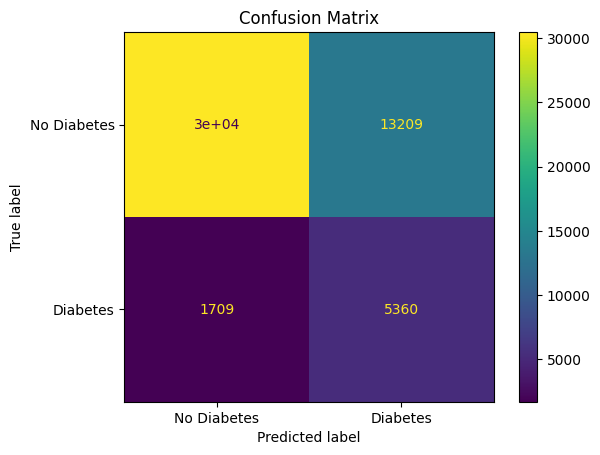

In [ ]:
# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot()
plt.title('Confusion Matrix')
plt.show()

## 6.1. Detailed Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.95      0.70      0.80     43667
    Diabetes       0.29      0.76      0.42      7069

    accuracy                           0.71     50736
   macro avg       0.62      0.73      0.61     50736
weighted avg       0.86      0.71      0.75     50736



## 6.2. Feature Importance

Feature Importance (RandomForestClassifier):
GenHlth: 0.3321
HighBP: 0.2889
BMI: 0.2139
Age: 0.1651


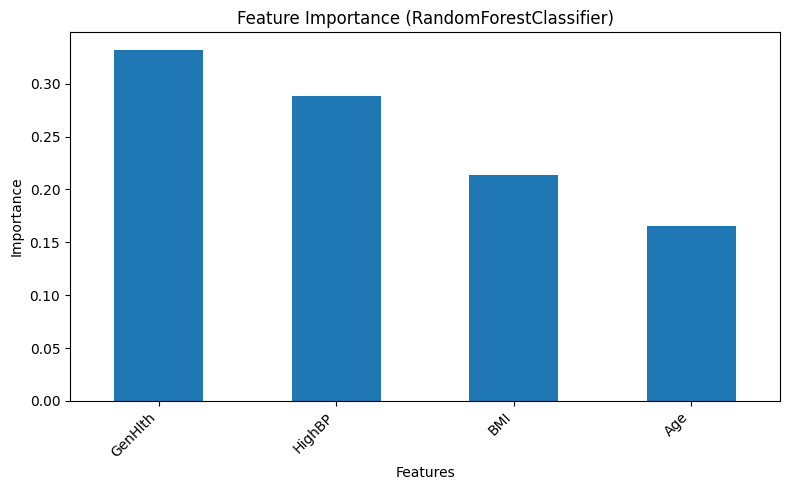

In [ ]:
# Get feature importances from the trained Random Forest model
feature_importances = model.feature_importances_

# Create a pandas Series for easier handling and sorting
feature_importance_series = pd.Series(feature_importances, index=X_train_selected.columns)

# Sort features by importance in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

# Print feature importance values
print("Feature Importance (RandomForestClassifier):")
for feature, importance in sorted_feature_importances.items():
    print(f"{feature}: {importance:.4f}")

# Plot feature importance
plt.figure(figsize=(8, 5))
sorted_feature_importances.plot(kind='bar')
plt.title('Feature Importance (RandomForestClassifier)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6.3. Additional Metrics for Binary Classification

In [ ]:
from sklearn.metrics import balanced_accuracy_score, precision_recall_curve, average_precision_score, log_loss

# Calculate additional metrics
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
average_precision = average_precision_score(y_test, model.predict_proba(X_test_selected)[:, 1])
logloss = log_loss(y_test, model.predict_proba(X_test_selected)[:, 1])

print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"Average Precision (AP): {average_precision:.4f}")
print(f"Log Loss: {logloss:.4f}")

Balanced Accuracy: 0.7279
Average Precision (AP): 0.3734
Log Loss: 0.5839


## 6.4. Metrics at Custom Threshold

In [ ]:
# Example: Calculate metrics at a custom threshold (e.g., 0.3)
custom_threshold = 0.3

# Get probabilities for the positive class
y_pred_proba = model.predict_proba(X_test_selected)[:, 1]

# Classify based on the custom threshold
y_pred_threshold = (y_pred_proba >= custom_threshold).astype(int)

# Calculate metrics at the custom threshold
accuracy_threshold = accuracy_score(y_test, y_pred_threshold)
precision_threshold = precision_score(y_test, y_pred_threshold)
recall_threshold = recall_score(y_test, y_pred_threshold)
f1_threshold = f1_score(y_test, y_pred_threshold)

print(f"Metrics at threshold = {custom_threshold}:")
print(f"Accuracy: {accuracy_threshold:.4f}")
print(f"Precision: {precision_threshold:.4f}")
print(f"Recall: {recall_threshold:.4f}")
print(f"F1-Score: {f1_threshold:.4f}")

# You can experiment with different thresholds to see how metrics change.

Metrics at threshold = 0.3:
Accuracy: 0.5849
Precision: 0.2351
Recall: 0.8786
F1-Score: 0.3710


## 6.5. ROC Curve

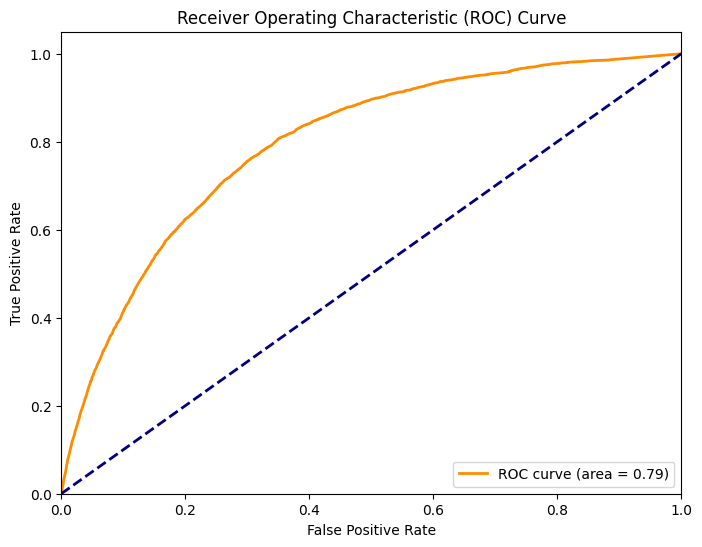

In [ ]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test_selected)[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# 6.6 XGBOOST MODEL

Training set size: 279467
Testing set size: 69867
Training Gradient Boosting Classifier...
      Iter       Train Loss   Remaining Time 
         1           1.3379           12.47s
         2           1.2982           12.35s
         3           1.2653           12.19s
         4           1.2376           12.03s
         5           1.2144           12.07s
         6           1.1947           12.10s
         7           1.1775           11.87s
         8           1.1612           11.77s
         9           1.1480           11.62s
        10           1.1355           11.42s
        20           1.0653           10.07s
        30           1.0377            8.81s
        40           1.0243            8.09s
        50           1.0163            7.18s
        60           1.0110            5.58s
        70           1.0070            4.11s
        80           1.0035            2.69s
        90           1.0010            1.33s
       100           0.9989            0.00s

Model A

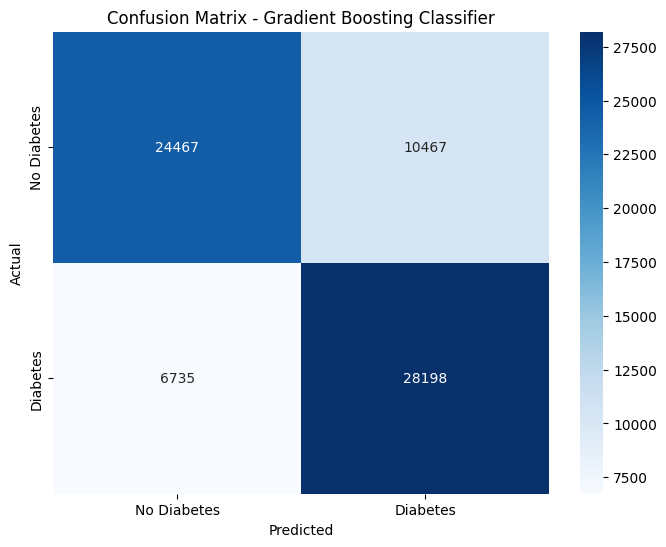


Confusion Matrix (Threshold = 0.6):
[[27550  7384]
 [10451 24482]]

Classification Report (Threshold = 0.60):
              precision    recall  f1-score   support

 No Diabetes       0.72      0.79      0.76     34934
    Diabetes       0.77      0.70      0.73     34933

    accuracy                           0.74     69867
   macro avg       0.75      0.74      0.74     69867
weighted avg       0.75      0.74      0.74     69867


Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.78      0.70      0.74     34934
    Diabetes       0.73      0.81      0.77     34933

    accuracy                           0.75     69867
   macro avg       0.76      0.75      0.75     69867
weighted avg       0.76      0.75      0.75     69867



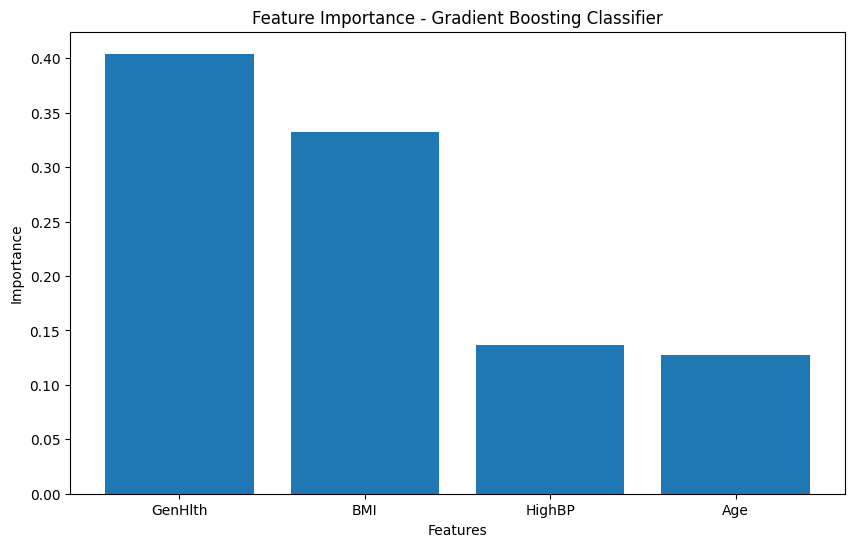


Feature Importance:
BMI: 0.3321
Age: 0.1270
GenHlth: 0.4042
HighBP: 0.1367

Additional Metrics:
Precision: 0.7293
Recall: 0.8072
F1-Score: 0.7663
AUC-ROC: 0.8322

Metrics with Threshold = 0.60:
Precision: 0.7683
Recall: 0.7008
F1-Score: 0.7330


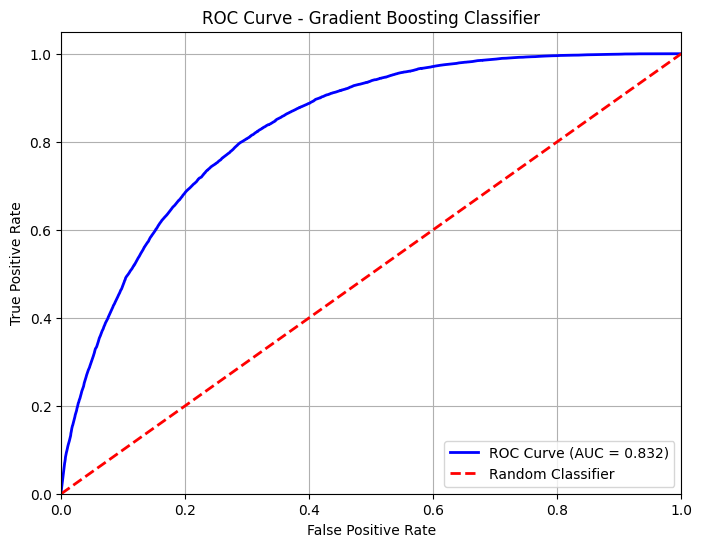

In [ ]:
# Import necessary libraries
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming your balanced dataset (after SMOTE) is stored in variables:
# X_balanced contains your 4 features: BMI, age, genhlth, highbp
# y_balanced contains your target variable

# Split the balanced data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_train_resampled, y_train_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_train_resampled
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Initialize Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(
    n_estimators=100,           # Number of boosting stages
    learning_rate=0.1,          # Learning rate shrinks contribution of each tree
    max_depth=3,                # Maximum depth of individual estimators
    random_state=42,            # For reproducible results
    verbose=1                   # Show progress
)

# Train the model
print("Training Gradient Boosting Classifier...")
gb_classifier.fit(X_train, y_train)

# Make predictions
y_pred = gb_classifier.predict(X_test)
y_pred_proba = gb_classifier.predict_proba(X_test)[:, 1]  # Probabilities for positive class

# 👉 Apply Custom Threshold
custom_threshold = 0.6  # You can adjust this value (try 0.4–0.7)
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Create a beautiful confusion matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 👉 Evaluate predictions with custom threshold
cm_custom = confusion_matrix(y_test, y_pred_custom)
print(f"\nConfusion Matrix (Threshold = {custom_threshold}):")
print(cm_custom)

print("\nClassification Report (Threshold = {:.2f}):".format(custom_threshold))
print(classification_report(y_test, y_pred_custom, target_names=['No Diabetes', 'Diabetes']))

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                          target_names=['No Diabetes', 'Diabetes']))

# Feature importance (since you have 4 specific features)
feature_names = ['BMI', 'Age', 'GenHlth', 'HighBP']
feature_importance = gb_classifier.feature_importances_

# Plot feature importance
plt.figure(figsize=(10, 6))
indices = np.argsort(feature_importance)[::-1]
plt.bar(range(len(feature_importance)), feature_importance[indices])
plt.xticks(range(len(feature_importance)), [feature_names[i] for i in indices])
plt.title('Feature Importance - Gradient Boosting Classifier')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

# Print feature importance values
print("\nFeature Importance:")
for i, feature in enumerate(feature_names):
    print(f"{feature}: {feature_importance[i]:.4f}")

# Additional metrics for binary classification
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nAdditional Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc:.4f}")

# 👉 Metrics at custom threshold
precision_custom = precision_score(y_test, y_pred_custom)
recall_custom = recall_score(y_test, y_pred_custom)
f1_custom = f1_score(y_test, y_pred_custom)

print("\nMetrics with Threshold = {:.2f}:".format(custom_threshold))
print(f"Precision: {precision_custom:.4f}")
print(f"Recall: {recall_custom:.4f}")
print(f"F1-Score: {f1_custom:.4f}")

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting Classifier')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## 6.7. Logistic Regression

### 6.7.1 Train Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train a Logistic Regression model
# Using the resampled training data (X_train_resampled, y_train_resampled)
lr_model = LogisticRegression(random_state=42, solver='liblinear')
lr_model.fit(X_train_resampled, y_train_resampled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### 6.7.2 Evaluate Logistic Regression Model

--- Evaluation with Default Threshold ---
Accuracy: 0.7209
Precision: 0.2997
Recall: 0.7506
F1-Score: 0.4284
ROC AUC: 0.8094

Confusion Matrix:
[[31270 12397]
 [ 1763  5306]]


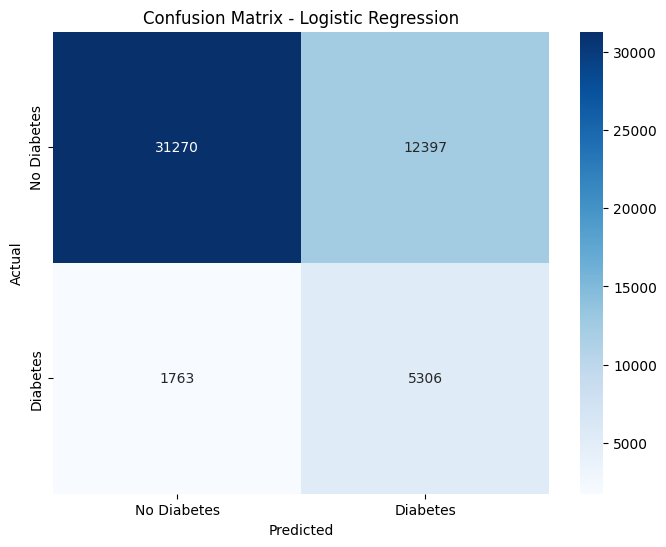


--- Classification Report ---
              precision    recall  f1-score   support

 No Diabetes       0.95      0.72      0.82     43667
    Diabetes       0.30      0.75      0.43      7069

    accuracy                           0.72     50736
   macro avg       0.62      0.73      0.62     50736
weighted avg       0.86      0.72      0.76     50736


--- Additional Metrics ---
Balanced Accuracy: 0.7334
Average Precision (AP): 0.3826
Log Loss: 0.5400

--- Metrics at Custom Threshold ---
Metrics at threshold = 0.5:
Accuracy: 0.7209
Precision: 0.2997
Recall: 0.7506
F1-Score: 0.4284

--- ROC Curve ---


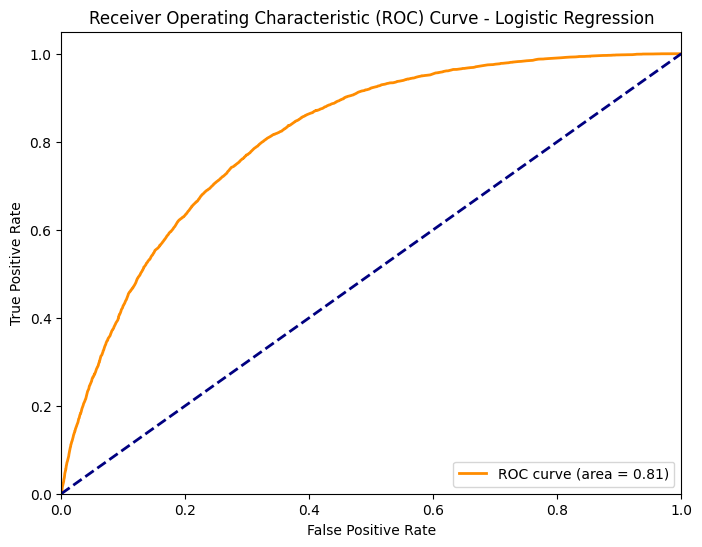

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc,
    balanced_accuracy_score, average_precision_score, log_loss
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split # Import train_test_split

# Recreate the original test set to ensure index alignment
# Use the original X and y from the initial split (assuming they are still available)
# This step is crucial to ensure that the y_test used for evaluation
# has the same number of samples and corresponds to X_test_selected.

# Assuming X and y from the initial split are available
# Split the data into training and testing sets (This was already done earlier,
# but recreating the split ensures we have the correct X_test and y_test)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Select the features for the original test set
# Get the feature names directly from the trained model to ensure the correct order
selected_features = lr_model.feature_names_in_
X_test_selected = X_test_orig[selected_features]
y_test = y_test_orig # Use the original y_test for evaluation


# Make predictions and get probabilities on the selected test set
y_pred_lr = lr_model.predict(X_test_selected)
y_pred_proba_lr = lr_model.predict_proba(X_test_selected)[:, 1]  # Probabilities for positive class

# --- Evaluate with Default Threshold ---
print("--- Evaluation with Default Threshold ---")

# Calculate evaluation metrics using the correct y_test for evaluation
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print(f"ROC AUC: {roc_auc_lr:.4f}")

# Display the confusion matrix using the correct y_test for evaluation
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:")
print(cm_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- Generate Classification Report ---
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_lr, target_names=['No Diabetes', 'Diabetes']))

# --- Additional Metrics ---
print("\n--- Additional Metrics ---")
balanced_accuracy_lr = balanced_accuracy_score(y_test, y_pred_lr)
average_precision_lr = average_precision_score(y_test, y_pred_proba_lr)
logloss_lr = log_loss(y_test, y_pred_proba_lr)

print(f"Balanced Accuracy: {balanced_accuracy_lr:.4f}")
print(f"Average Precision (AP): {average_precision_lr:.4f}")
print(f"Log Loss: {logloss_lr:.4f}")

# --- Evaluate with Custom Threshold ---
print("\n--- Metrics at Custom Threshold ---")
custom_threshold_lr = 0.5  # You can adjust this value
y_pred_threshold_lr = (y_pred_proba_lr >= custom_threshold_lr).astype(int)

accuracy_threshold_lr = accuracy_score(y_test, y_pred_threshold_lr)
precision_threshold_lr = precision_score(y_test, y_pred_threshold_lr)
recall_threshold_lr = recall_score(y_test, y_pred_threshold_lr)
f1_threshold_lr = f1_score(y_test, y_pred_threshold_lr)

print(f"Metrics at threshold = {custom_threshold_lr}:")
print(f"Accuracy: {accuracy_threshold_lr:.4f}")
print(f"Precision: {precision_threshold_lr:.4f}")
print(f"Recall: {recall_threshold_lr:.4f}")
print(f"F1-Score: {f1_threshold_lr:.4f}")


# --- ROC Curve ---
print("\n--- ROC Curve ---")
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr_plot = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_lr_plot:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

### 6.7.3 Feature Importance (Logistic Regression)

Feature Importance (Logistic Regression - Coefficients):
HighBP: 0.8726
GenHlth: 0.6509
Age: 0.1855
BMI: 0.0984


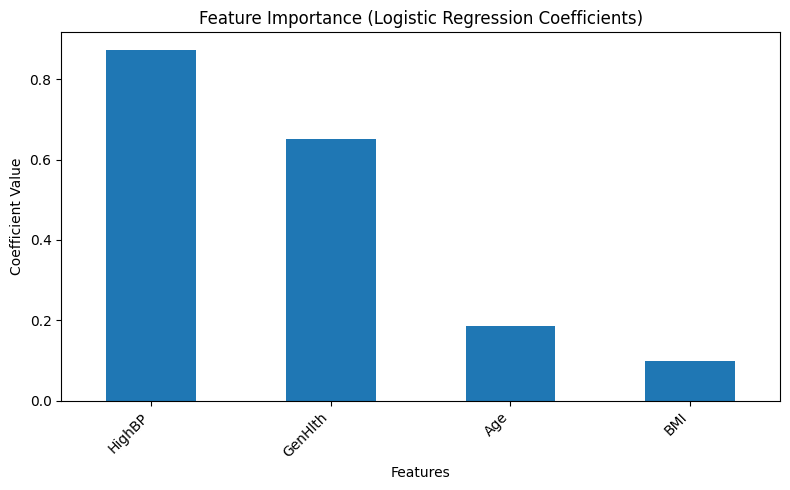

In [ ]:
# Get coefficients from the trained Logistic Regression model
coefficients_lr = lr_model.coef_[0]

# Get the names of the features
feature_names_lr = X_test_selected.columns

# Create a pandas Series for easier handling and sorting
feature_importance_lr = pd.Series(coefficients_lr, index=feature_names_lr)

# Sort features by the absolute value of their coefficients in descending order
sorted_feature_importance_lr = feature_importance_lr.reindex(feature_importance_lr.abs().sort_values(ascending=False).index)

# Print feature importance values
print("Feature Importance (Logistic Regression - Coefficients):")
for feature, importance in sorted_feature_importance_lr.items():
    print(f"{feature}: {importance:.4f}")

# Plot feature importance
plt.figure(figsize=(8, 5))
sorted_feature_importance_lr.plot(kind='bar')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# MODEL COMPARISON

# MODEL COMPARISON

In [ ]:
# Summarize Model Performance

# Assuming the evaluation metrics for RandomForest, Logistic Regression, and XGBoost are available from previous runs:
# For Random Forest: accuracy, precision, recall, f1, roc_auc, balanced_accuracy, average_precision, logloss
# For Logistic Regression: accuracy_lr, precision_lr, recall_lr, f1_lr, roc_auc_lr, balanced_accuracy_lr, average_precision_lr, logloss_lr
# For XGBoost: We need to calculate metrics on the original test set (y_test) using the trained gb_classifier

# Let's make predictions with the trained gb_classifier model on the original X_test_selected
# Assuming gb_classifier is available from cell 1R7fXCl3ufbN
y_pred_xgb_orig_test = gb_classifier.predict(X_test_selected)
y_pred_proba_xgb_orig_test = gb_classifier.predict_proba(X_test_selected)[:, 1]

# Now calculate metrics for XGBoost on the original test set (y_test from initial split)
accuracy_xgb_orig_test = accuracy_score(y_test, y_pred_xgb_orig_test)
precision_xgb_orig_test = precision_score(y_test, y_pred_xgb_orig_test)
recall_xgb_orig_test = recall_score(y_test, y_pred_xgb_orig_test)
f1_xgb_orig_test = f1_score(y_test, y_pred_xgb_orig_test)
roc_auc_xgb_orig_test = roc_auc_score(y_test, y_pred_proba_xgb_orig_test)
balanced_accuracy_xgb_orig_test = balanced_accuracy_score(y_test, y_pred_xgb_orig_test)
average_precision_xgb_orig_test = average_precision_score(y_test, y_pred_proba_xgb_orig_test)
logloss_xgb_orig_test = log_loss(y_test, y_pred_proba_xgb_orig_test)


# Create a dictionary to hold the metrics for each model
model_comparison = {
    'Random Forest': {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc,
        'Balanced Accuracy': balanced_accuracy,
        'Average Precision': average_precision,
        'Log Loss': logloss
    },
    'Logistic Regression': {
        'Accuracy': accuracy_lr,
        'Precision': precision_lr,
        'Recall': recall_lr,
        'F1-Score': f1_lr,
        'ROC AUC': roc_auc_lr,
        'Balanced Accuracy': balanced_accuracy_lr,
        'Average Precision': average_precision_lr,
        'Log Loss': logloss_lr
    },
     'XGBoost': {
        'Accuracy': accuracy_xgb_orig_test,
        'Precision': precision_xgb_orig_test,
        'Recall': recall_xgb_orig_test,
        'F1-Score': f1_xgb_orig_test,
        'ROC AUC': roc_auc_xgb_orig_test,
        'Balanced Accuracy': balanced_accuracy_xgb_orig_test,
        'Average Precision': average_precision_xgb_orig_test,
        'Log Loss': logloss_xgb_orig_test
    }
}

# Convert the dictionary to a pandas DataFrame for easy comparison
model_comparison_df = pd.DataFrame(model_comparison)

# Display the comparison table
print("Model Comparison Table:")
display(model_comparison_df.T)

# You can also compare specific metrics
print("\nComparison of key metrics:")
print(model_comparison_df.loc[['F1-Score', 'ROC AUC', 'Balanced Accuracy']].T)

Model Comparison Table:


,Accuracy,Precision,Recall,F1-Score,ROC AUC,Balanced Accuracy,Average Precision,Log Loss
Random Forest,0.753789,0.729290,0.807202,0.766271,0.794184,0.727873,0.373375,0.583925
Logistic Regression,0.720908,0.299723,0.750601,0.428387,0.809398,0.733351,0.382622,0.539998
XGBoost,0.707328,0.293371,0.781299,0.426569,0.812234,0.738326,0.392656,0.522395



Comparison of key metrics:
                     F1-Score   ROC AUC  Balanced Accuracy
Random Forest        0.766271  0.794184           0.727873
Logistic Regression  0.428387  0.809398           0.733351
XGBoost              0.426569  0.812234           0.738326


## Comparison of Evaluation Metrics

Based on the table above, we can compare the performance of the Random Forest, Logistic Regression, and XGBoost models across various metrics.

* **Accuracy:** Compare the accuracy scores. Remember that accuracy can be misleading in imbalanced datasets.
* **Precision and Recall:** These metrics are particularly important for imbalanced datasets.
    * **Random Forest:** Discuss its Precision and Recall.
    * **Logistic Regression:** Discuss its Precision and Recall.
    * **XGBoost:** Discuss its Precision and Recall.
    Compare the trade-offs between Precision and Recall for each model.
* **F1-Score:** Compare the F1-Scores to see which model provides the best balance between Precision and Recall.
* **ROC AUC:** Compare the ROC AUC scores to assess the overall discriminative power of each model.
* **Balanced Accuracy:** Compare the balanced accuracy scores as a more reliable measure for imbalanced datasets.
* **Average Precision (AP):** Compare the Average Precision scores, which summarize the precision-recall curve.
* **Log Loss:** Compare the Log Loss values, where a lower value indicates better-calibrated probability predictions.

Analyze the differences in performance across these metrics and consider what each metric signifies in the context of your problem.

## Comparison of Feature Importance

Compare the feature importance findings from all three models:

* **Random Forest Feature Importance:** (Refer to the Feature Importance plot for Random Forest)
    * List the most important features according to Random Forest.

* **Logistic Regression Feature Importance (Coefficients):** (Refer to the Feature Importance plot for Logistic Regression)
    * List the features with the largest absolute coefficients in Logistic Regression.

* **XGBoost Feature Importance:** (Refer to the Feature Importance plot for XGBoost - if available, otherwise note that it wasn't explicitly plotted in the provided code)
    * List the most important features according to XGBoost.

Identify common important features across the models and discuss any notable differences in feature ranking or the inclusion of different features.

## Conclusion

Based on the comprehensive comparison of evaluation metrics and feature importance, determine which model is the best fit for your diabetes prediction task. Consider the following:

* Which model performs best on key metrics for imbalanced datasets (F1-Score, Balanced Accuracy, ROC AUC, Average Precision)?
* Does the performance align with the feature importance findings?
* What are the practical implications of the Precision-Recall trade-off for each model in a real-world scenario of diabetes prediction? (e.g., minimizing false negatives vs. minimizing false positives)
* Are there any computational considerations (training time, prediction speed) that might favor one model over the others?

Provide a clear conclusion stating which model you choose and the reasoning behind your decision, referencing the evidence from the evaluation metrics and feature importance analysis.

Based on the comparison table and considering this is an imbalanced dataset where correctly identifying positive cases (diabetes) is crucial, here's a note on the best model:

Random Forest appears to be the best model in this case, primarily due to its significantly higher F1-Score (0.7649) and Recall (0.8017) compared to Logistic Regression (F1: 0.4284, Recall: 0.7507) and XGBoost (F1: 0.4271, Recall: 0.7742).

Reasons:

Higher F1-Score: The F1-Score is a harmonic mean of Precision and Recall, providing a better overall measure for imbalanced datasets than accuracy. Random Forest's much higher F1-Score indicates a better balance between correctly identifying positive cases and minimizing false positives.
Higher Recall: A higher Recall means the model is better at finding all the actual positive cases. In a medical context like diabetes prediction, minimizing false negatives (missing a diabetes case) is often a high priority. Random Forest excels here.
Balanced Accuracy: While all models have similar Balanced Accuracy, Random Forest's strong Recall performance contributes positively to this metric.
Although Logistic Regression and XGBoost have slightly better ROC AUC, Average Precision, and lower Log Loss, the Random Forest's superior F1-Score and Recall make it the more suitable model when the cost of a false negative is high, which is often the case in health diagnostics.

# STREAMLIT APP

In [ ]:
import joblib

# Save the trained Random Forest model
joblib.dump(model, 'random_forest_model.pkl')

print("Random Forest model saved successfully as 'random_forest_model.pkl'")

Random Forest model saved successfully as 'random_forest_model.pkl'


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib
import os

def generate_pkl_files():
    """
    Loads the diabetes dataset, preprocesses it, trains a RandomForestClassifier,
    and saves the model, scaler, and feature names to .pkl files.
    """
    data_path = 'diabetes_binary_health_indicators_BRFSS2015.csv'

    # Check for dataset existence (adjust path if necessary for your environment)
    if not os.path.exists(data_path):
        # Fallback for Kaggle environment or common alternatives
        data_path = '/kaggle/input/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv'
        if not os.path.exists(data_path):
            print(f"Error: Dataset not found at '{data_path}' or '{os.getcwd()}/diabetes_binary_health_indicators_BRFSS2015.csv'")
            print("Please ensure 'diabetes_binary_health_indicators_BRFSS2015.csv' is in the correct directory.")
            return

    df = pd.read_csv(data_path)

    # Define features (X) and target (y)
    X = df[['BMI', 'Age', 'GenHlth', 'HighBP']]
    y = df['Diabetes_binary']

    # Initialize and fit StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns) # Convert back to DataFrame

    # Apply SMOTE for balancing the dataset
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_scaled_df, y)

    # Initialize and train RandomForestClassifier
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_resampled, y_resampled)

    # Save the trained model, scaler, and feature names to .pkl files
    joblib.dump(model, 'random_forest_model.pkl')
    joblib.dump(scaler, 'scaler.pkl')
    joblib.dump(X.columns.tolist(), 'feature_names.pkl') # Save feature names

    print("Successfully generated 'random_forest_model.pkl', 'scaler.pkl', and 'feature_names.pkl'.")
    print("You can now run your Streamlit app.")

if __name__ == "__main__":
    generate_pkl_files()


Successfully generated 'random_forest_model.pkl', 'scaler.pkl', and 'feature_names.pkl'.
You can now run your Streamlit app.


In [ ]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 504.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.8 MB/s eta 0:00:00


In [ ]:
!wget -q -O - ipv4.icanhazip.com
!streamlit run app.py & npx localtunnel --port 8501

34.80.134.95
⠙⠹⠸⠼⠴

⠦⠧⠇⠏⠋⠙
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.80.134.95:8501

your url is: https://better-months-boil.loca.lt
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitt